In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# import dataset
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [3]:
train.head()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


In [4]:
test.head()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact
0,691369,30.0,9.34,NaN,0.77,4.09,7.15,153.0,16.0,NaN,Other,Medium,Yes
1,691370,NaN,NaN,1.91,NaN,1.20,8.67,239.0,148.0,10.68,Female,High,No
2,691371,26.0,8.48,3.64,NaN,3.39,7.47,106.0,123.0,NaN,Male,NaN,No
3,691372,20.0,8.37,2.99,1.69,2.53,5.45,178.0,55.0,9.88,Male,High,Yes
4,691373,25.0,8.25,4.02,1.21,2.32,8.46,63.0,86.0,10.72,Male,Low,No


In [5]:
print(train.shape)
print(test.shape)

(691369, 14)
(296302, 13)


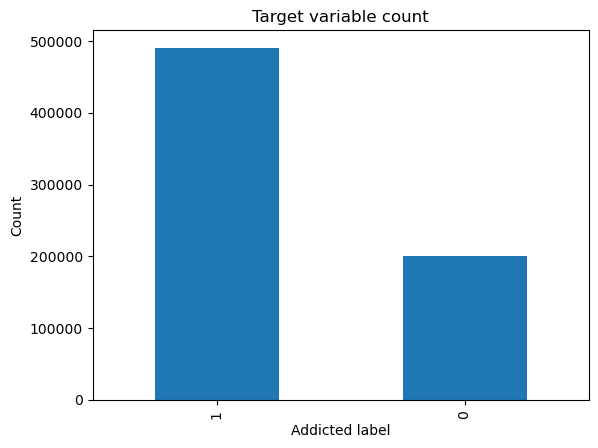

In [6]:
train['addicted_label'].value_counts().plot(kind='bar')

plt.title("Target variable count")
plt.xlabel("Addicted label")
plt.ylabel("Count")
plt.show()

In [7]:
print(train.isnull().sum())
print()
print(test.isnull().sum())

id                              0
age                         28929
daily_screen_time_hours     95854
social_media_hours         133995
gaming_hours               126821
work_study_hours            51518
sleep_hours                 44480
notifications_per_day       67584
app_opens_per_day           80710
weekend_screen_time        112063
gender                      29034
stress_level                55148
academic_work_impact        44224
addicted_label                  0
dtype: int64

id                             0
age                        17138
daily_screen_time_hours    32788
social_media_hours         47397
gaming_hours               59420
work_study_hours           27777
sleep_hours                22455
notifications_per_day      34221
app_opens_per_day          25705
weekend_screen_time        50697
gender                     14212
stress_level               19626
academic_work_impact       25721
dtype: int64


In [8]:
train.columns

Index(['id', 'age', 'daily_screen_time_hours', 'social_media_hours',
       'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'gender', 'stress_level', 'academic_work_impact', 'addicted_label'],
      dtype='object')

In [9]:
numeric_cols = ['age', 'daily_screen_time_hours', 'social_media_hours',
       'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time']

categoric_cols = ['gender', 'stress_level', 'academic_work_impact']

In [10]:
# SIMPLE IMPUTER TO HANDLE MISSING VALUES
from sklearn.impute import SimpleImputer
n_imputer = SimpleImputer(strategy = "median")

train[numeric_cols] = n_imputer.fit_transform(train[numeric_cols])
test[numeric_cols] = n_imputer.transform(test[numeric_cols])

In [11]:
#
c_imputer = SimpleImputer(strategy = "most_frequent")

train[categoric_cols] = c_imputer.fit_transform(train[categoric_cols])
test[categoric_cols] = c_imputer.transform(test[categoric_cols])

In [12]:
# train - test - split
x_train = train.drop(columns=['id', 'addicted_label'])
y_train = train['addicted_label']

x_test = test.drop(columns = ['id'])

In [13]:
# encoding categorical values
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore').set_output(transform="pandas")

x_train = x_train.drop(columns=categoric_cols).join(ohe.fit_transform(x_train[categoric_cols]))
x_test = x_test.drop(columns=categoric_cols).join(ohe.transform(x_test[categoric_cols]))

In [14]:
# Scaling numeric values
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

## Logistic Regressor

In [15]:
#logistic regression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)

lr.fit(x_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [16]:
y_pred = lr.predict(x_test_scaled)

In [17]:
# validation set for roc auc & log loss
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, log_loss

x_trn, x_val, y_trn, y_val = train_test_split(x_train, y_train, test_size=0.2, stratify=y_train, random_state=42)

scaler_val = StandardScaler()
x_trn_scaled = scaler_val.fit_transform(x_trn)
x_val_scaled = scaler_val.transform(x_val)

lr.fit(x_trn_scaled, y_trn)
val_prob = lr.predict_proba(x_val_scaled)[:, 1]

In [18]:
print("ROC AUC Score:", roc_auc_score(y_val, val_prob))
print("Log Loss:", log_loss(y_val, val_prob))

ROC AUC Score: 0.9107533737592117
Log Loss: 0.3934953797151876


In [19]:
lr.fit(x_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [20]:
#output table

test_probability = lr.predict_proba(x_test_scaled)[:,1]

output_df = pd.DataFrame({
    'id' : test['id'],
    'predicted_probability': test_probability
})

In [21]:
output_df.head(10)

,id,predicted_probability
0,691369,0.793097
1,691370,0.741582
2,691371,0.932175
3,691372,0.837794
4,691373,0.968999
5,691374,0.691738
6,691375,0.563637
7,691376,0.202348
8,691377,0.927533
9,691378,0.706190
